In [1]:
import equinox as eqx
import inspect
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import frugal_flows

from frugal_flows.basic_flows import (masked_independent_flow, 
                                        masked_autoregressive_flow_first_uniform, 
                                        masked_autoregressive_flow_masked_cond)
from frugal_flows.bijections import UnivariateNormalCDF
from frugal_flows.causal_flows import (train_frugal_flow, 
                                        train_copula_flow, 
                                        get_independent_quantiles, 
                                        univariate_discrete_cdf,
                                        independent_continuous_marginal_flow)
from frugal_flows.train_quantile_propensity_score import train_quantile_propensity_score

import flowjax
from flowjax.distributions import Transformed, Uniform, _StandardUniform
from flowjax.flows import masked_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.bijections.utils import Identity
from flowjax.bijections import (
    Affine,
    Invert,
    MaskedAutoregressive,
    RationalQuadraticSpline,
    Stack,
    Tanh,
)
import pandas as pd

SEED = 0

jax.config.update("jax_enable_x64", True)

In [2]:
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import optax
from flowjax.bijections import (
    Affine,
    Concatenate,
    Invert,
    RationalQuadraticSpline,
    Stack,
    Tanh,
)
from flowjax.bijections.utils import Identity
from flowjax.distributions import Transformed, Uniform, _StandardUniform
from flowjax.flows import masked_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.utils import get_ravelled_pytree_constructor
from jaxtyping import ArrayLike

from frugal_flows.basic_flows import (
    masked_autoregressive_bijection_masked_condition,
    masked_autoregressive_flow_first_uniform,
    masked_independent_flow,
    univariate_marginal_flow,
)
from frugal_flows.bijections import LocCond, UnivariateNormalCDF
SEED = 3

In [3]:
keys = jr.split(jr.PRNGKey(SEED+6), 50)

N = 10000

z_0 = jr.multivariate_normal(keys[0], jnp.array([0.,0.]), jnp.array([[1., 0],[0, 1.]]), shape=(int(N/2),))

z_1 = jr.multivariate_normal(keys[1], jnp.array([0.,0.]), jnp.array([[1., 0.8],[0.8, 1.]]), shape=(int(N/2),))
z = jnp.vstack([z_0, z_1])

x = jnp.hstack([jnp.zeros((int(N/2))),jnp.ones((int(N/2)))])

# x = jnp.expand_dims(jnp.hstack([jnp.ones(int(N/2))*0, jnp.ones(int(N/2))*1]),axis=1)
y = jax.random.normal(keys[2], shape=(N,1)) + jnp.expand_dims(z.sum(1), axis=1) + x[:,None]

A Google TPU may be present on this machine, but either a TPU-enabled jaxlib or libtpu is not installed. Falling back to cpu.


# Refresher 

Recall that a Masked Autoregressive Flow (MAF) is a composition of layers, where each layer is an affine bijection (called the "transformer"), that retrieves its scale and location parameters from a MLP that has an autoregressive structure. The same architecture where the transformer is a rational quadratic spline instead of an affine bijection is called Neural Spline Flow (NSF). In that case the MLP has to produce the parameters of the spline (and still preserve an autoregressive structure).

In `FlowJax` a simple unconditional NSF can be implemented as follows:
1) Imagine you have data w of shape (n_samples, w_dim)
2) Pick a base distribution e.g. Uniform of shape w_dim
3) Pass 

# Marginal flows

In [4]:
z_res = get_independent_quantiles(key = jr.PRNGKey(3),
                                z_cont=z,
                                max_epochs = 70,
                                max_patience=10,
                                return_z_cont_flow = True,
                             )

 33%|█████████████▏                          | 23/70 [00:09<00:19,  2.35it/s, train=1.42, val=1.43 (Max patience reached)]


`get_independent_quantiles()` returns a dictionary with (i) the $U_z$ samples corresponding to the continuous $Z$ variables, (ii) the $U_z$ samples corresponding to the discrete $Z$ variables, (iii) the $U_z$ flow objects for the contiuous $Z$ variables.

In [5]:
z_res.keys()

dict_keys(['u_z_cont', 'u_z_discr', 'z_cont_flows'])

If you pass a continuous $Z$ to its respective flow you'll see it gives you back $U_z$! 

In [24]:
marg_flow_z0 = z_res['z_cont_flows'][0]
u_z_cont0_reconstr = jax.vmap(marg_flow_z0.bijection.inverse)(z[:,0].reshape(-1, 1))
jnp.array_equal(z_res['u_z_cont'][:,0:1], u_z_cont0_reconstr)

Array(True, dtype=bool)

... and reassuringly the $U_z$ samples are uniform!

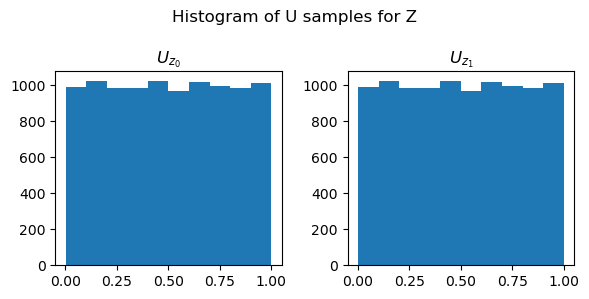

In [31]:
fig, ax = plt.subplots(1,2,figsize=(6,3))
fig.suptitle('Histogram of U samples for Z')
ax[0].hist(res['u_z_cont'][:,0])
ax[0].set_title(r'$U_{z_0}$')
ax[1].hist(res['u_z_cont'][:,0])
ax[1].set_title(r'$U_{z_1}$')
plt.tight_layout()
plt.show()

If you want to inspect the tree explore it: run `z_res['z_cont_flows'][i]` and then go deep by calling attributes like `bijection` and so on. In particular if you want to know the frozen parameters of a bijection that is marked as `Non-Trainable`, first identify it in the tree e.g.

In [29]:
aff_bij = z_res['z_cont_flows'][0].bijection.bijections[0]
aff_bij

Affine(
  shape=(1,),
  loc=NonTrainable(tree=NonTrainable(tree=f64[1])),
  scale=Parameterize(
    fn=<PjitFunction of <function softplus at 0x7fb3182b5440>>,
    args=(NonTrainable(tree=NonTrainable(tree=f64[1])),),
    kwargs={}
  )
)

and then explore its parameters after having unwrapped the `NonTrainable` object with the `paramax` package:

In [34]:
import paramax
paramax.unwrap(aff_bij).loc, paramax.unwrap(aff_bij).scale

(Array([-1.], dtype=float64), Array([2.], dtype=float64))

# Frugal Flow 

Now you need to train the frugal flow, using the function `train_frugal_flow()`. that sequentially models:
1) the causal margin, as either:
   - a gaussian inverse CDF that is conditioned on the treatment $x$: y 
   - a Neural Spline Flow that is NOT conditioned on the treatment $x$ + an affine t.
   -
The main function is `train_frugal_flow()` and it wants the following as main arguments:
- key: jr.PRNGKey for the MAF permutations
- y: univariate outcome
- u_z: ArrayLike of the $U_z$
- RQS_knots: int of the desired knots for the spline of the MAF transformer
- nn_depth: int of the depth of the MAF MLP that gives the parameters of the spline
- nn_width: int of the width of the MAF MLP that gives the parameters of the spline
- flow_layers: int of the number of  width of the MAF MLP that gives the parameters of the spline
    show_progress: bool = True,
    learning_rate: float = 5e-4,
    max_epochs: int = 100,
    max_patience: int = 5,
    batch_size: int = 100,
    condition: ArrayLike | None = None,
    mask_condition: bool = True,
    causal_model="gaussian",
    causal_model_args: dict | None = None,

In [37]:
frugal_flow, losses = train_frugal_flow(key=keys[1],
                y=y,
                u_z=z_res['u_z_cont'],
                learning_rate=1e-3,
                max_patience=3,
                max_epochs=1,
                causal_model_args={'ate':jnp.array([5.]), 'const':2, 'scale':1.},
                condition=x[:,None],
             )

100%|███████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.98s/it, train=11.7, val=10.4]


### Gaussian causal margin

A Gaussian causal margin assumes the following model for the causal margin:
$$y = const + ate * x + scale* \epsilon \qquad \epsilon \sim N(0,1)$$
This `bijection` is implemented in the `UnivariateNormalCDF` bijection class.

The Gaussian inverse CDF for $u \rightarrow y $ (`transform()` method) is:

$$ y \sim const + ate * x + scale* \Phi^{-1}(u)$$

and the Gaussian CDF for $y \rightarrow u $ (`inverse()` method) is

$$ u \sim \Phi\left(\frac{y - const - ate * x}{scale}\right)$$



### Location translation causal margin

A location-translation causal margin assumes the following model for the causal margin:
$$y = ate * x + \epsilon \qquad \epsilon \sim \mathcal F$$

which first applies a Neural Spline Flow (NSF) and then applies an affine transformation. Since $x$ is binary, the ite for each Y is exactly
$$Y(1) - Y(0) = ate$$

and therefore the ATE is 
$$ATE = \mathbb E [Y(1) - Y(0)] = \mathbb E [ate] = ate$$




This `bijection` does not have a specific class, but rather composes i) a `FlowJax` `Affine` bijection with ii) a `FlowJax` `MaskedAutoregressiveMaskedCond` bijection with a `RationalQuadraticSpline` transformer, i.e. a Neural Spline Flow (NSF) that is NOT conditioned on $x$.

The location-translation inverse CDF for $u \rightarrow y $ (`transform()` method) is:

$$ y \sim const + ate * x + scale* \Phi^{-1}(u)$$

and the location-translation CDF for $y \rightarrow u $ (`inverse()` method) is

$$ u \sim \Phi\left(\frac{y - const - ate * x}{scale}\right)$$

In [35]:
frugal_flow

NameError: name 'frugal_flow' is not defined

In [ ]:
uni_standard = jr.uniform(keys[17], shape=(n_samples, flow_dim))
uni_minus1_plus1 = jax.vmap(frugal_flow.bijection.bijections[0].tree.transform)(uni_standard)

corruni_minus1_plus1 = jax.vmap(frugal_flow.bijection.bijections[1].transform)(uni_minus1_plus1)
corruni_standard = jax.vmap(frugal_flow.bijection.bijections[2].tree.transform)(corruni_minus1_plus1)